1300_horizontal.jpeg
1300_horizontal.jpeg


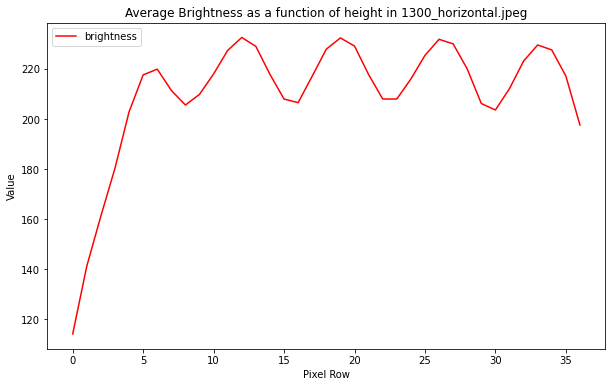

1300_vertical.jpeg


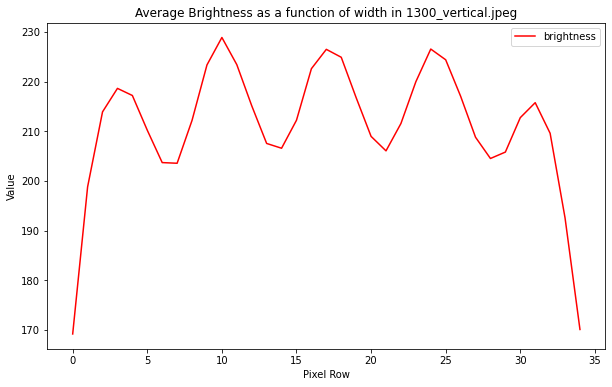

1400_horizontal.jpeg
1400_horizontal.jpeg


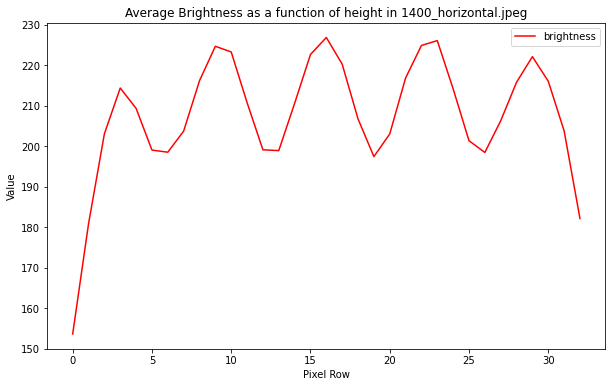

1400_vertical.jpeg


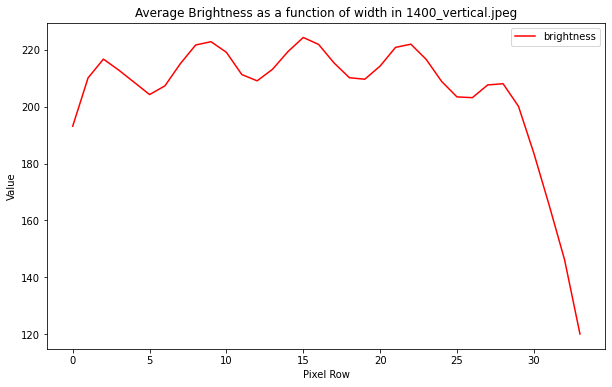

1600_horizontal.jpeg
1600_horizontal.jpeg


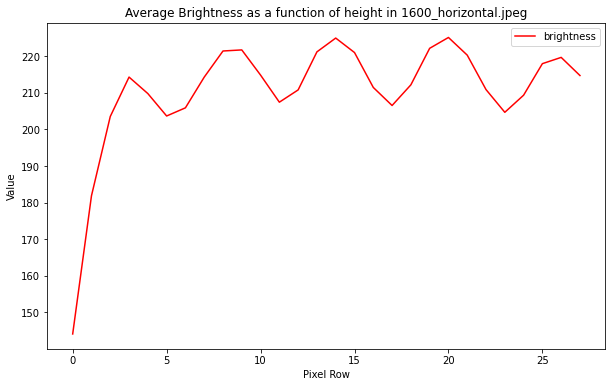

1600_veritcal.jpeg


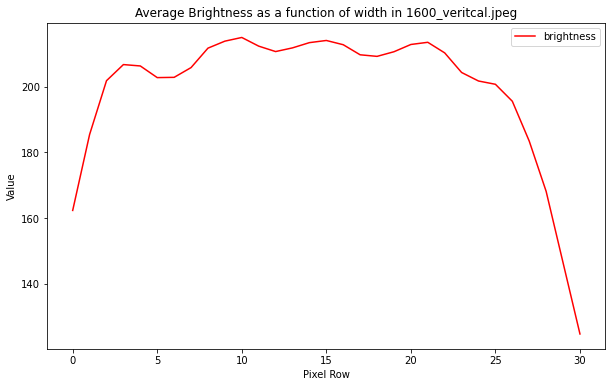

1800_horizontal.jpeg
1800_horizontal.jpeg


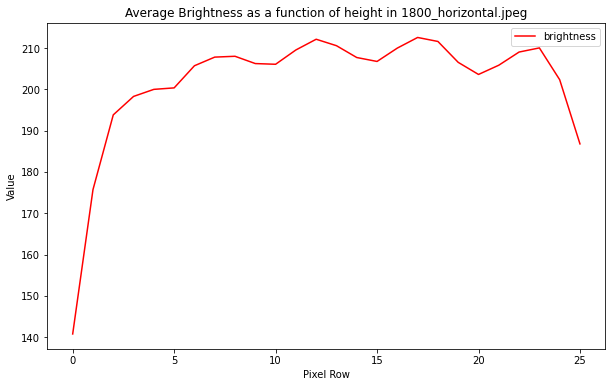

1800_veritcal.jpeg


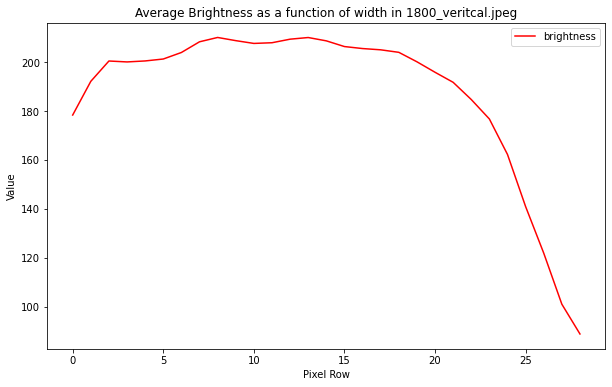

2000_horizontal.jpeg
2000_horizontal.jpeg


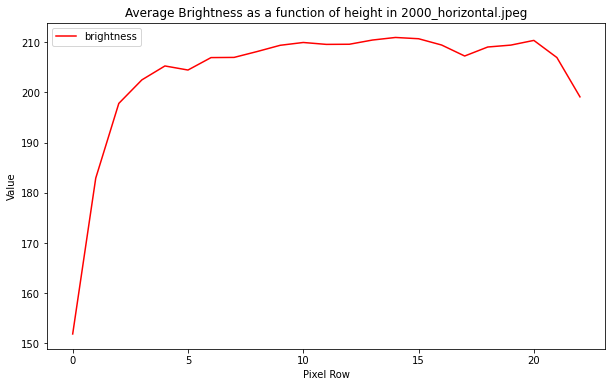

2000_vertical.jpeg


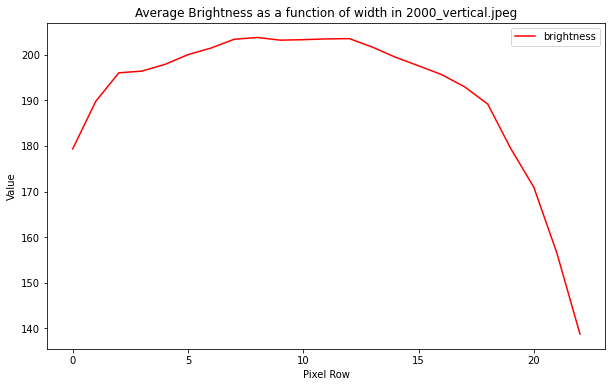

In [2]:
#python script to analyse brightness (top to bottom and left to right along and image)

import os
from os import listdir
from os.path import isfile, join
import glob
from PIL import Image
import matplotlib.pyplot as plt
import statistics
from scipy.fft import fft, ifft,fftfreq



def plot_figures(avg_brightness,direction,save=False):
    plt.figure(figsize=(10, 6))
    #print(len(avg_brightness))
    plt.plot(avg_brightness, label='brightness', color = 'red')
    
    plt.xlabel('Pixel Row')
    plt.ylabel('Value')
    plt.title(f'Average Brightness as a function of {direction} in {os.path.basename(file)}')
    #plt.title(f'Colours Apparents in file: {os.path.basename(file)}')
    plt.legend()

    if (save == True):
        plot_filename = os.path.join("picam2\improved_results", f"{os.path.basename(file)}.png")
        plt.savefig(plot_filename, format='png', bbox_inches='tight')

    
    
    # Show the plot
    plt.show()

    # Close the plot to free up memory
    plt.close()


def full_average_brightness_hoirz(image):
    
    width,height = image.size
    avg_brightness = []
    
    
    for y in range(height):
        brightnesses = []

        for x in range(width):
            r, g, b = image.getpixel((x, y))

            brightnesses.append((r + g + b) / 3)
            

        average = statistics.mean(brightnesses)
        avg_brightness.append(average)   
    
    plot_figures(avg_brightness, "height" , True)
    #rate_of_change(avg_brightness)
    

def full_average_brightness_vert(image):
    
    width,height = image.size
    avg_brightness = []
    
    
    for x in range(width):
        brightnesses = []

        for y in range(height):
            r, g, b = image.getpixel((x, y))

            brightnesses.append((r + g + b) / 3)
            

        average = statistics.mean(brightnesses)
        avg_brightness.append(average)   
    
    plot_figures(avg_brightness, "width",True )
    #rate_of_change(avg_brightness)


def rate_of_change(avg_brightness):
    derivative = []
    
    for i in range(len(avg_brightness) -1):
        derivative.append(abs(avg_brightness[i+1] - avg_brightness[i]))
    
    print(statistics.mean(derivative), "\n")
    
    
    
    
    
mypath = os.path.join(os.getcwd(), "picam2\cut_targets")

files = [os.path.join(mypath, f) for f in listdir(mypath) if isfile(join(mypath, f))]
 
for file in files:
    
    image = Image.open(file)
    filename = os.path.basename(file)
    print(filename)
    
    if filename.find("horizontal") != -1:
        print(filename)
        full_average_brightness_hoirz(image)  
    else:    
        full_average_brightness_vert(image)
    
    
    
    '''
    plot_figures(True)
    red_mean = statistics.mean(red)
    print("red mean:", red_mean)
    green_mean = statistics.mean(green)
    print("green mean:", green_mean)
    blue_mean = statistics.mean(blue)
    print("blue mean:", blue_mean)
    '''
    


